In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
from sklearn.compose import ColumnTransformer
import copy
import os
import pickle

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\Exercise2


In [20]:
cc_train = pd.read_csv("datasets/creditcard_train.csv")
cc_test = pd.read_csv("datasets/creditcard_test.csv")

cc_train = cc_train.drop("ID", axis = 1)
cc_test = cc_test.drop("ID", axis = 1)

In [21]:
def get_dummies_all(X_train, X_test):
    """
    Converts all categorical variables in a DataFrame into dummy (one-hot encoded) variables.
    """
    categorical_cols = ["MARRIAGE", "SEX", "EDUCATION"]  # Select categorical columns
    X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
    return X_train_encoded, X_test_encoded

In [22]:
X_train = cc_train.drop('default.payment.next.month', axis = 1)
X_test = cc_test.drop('default.payment.next.month', axis = 1)
y_train = cc_train['default.payment.next.month']
y_test = cc_test['default.payment.next.month']

X_train, X_test = get_dummies_all(X_train, X_test)

In [23]:
numeric_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
]

ordinal_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("ord", StandardScaler(), ordinal_features)
    ],
    remainder="passthrough"
)

X_train_sc = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)

X_test_sc = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

In [25]:
print(X_test_sc.head())

   num__LIMIT_BAL  num__AGE  num__BILL_AMT1  num__BILL_AMT2  num__BILL_AMT3  \
0       -1.057768 -1.136374       -0.573077       -0.547824       -0.507858   
1       -0.132786 -1.028090        1.169065        1.081980        1.009576   
2       -0.749441 -0.378385        0.261508        0.284330        0.314349   
3       -0.286950  1.462444       -0.412122       -0.422418       -0.441575   
4       -0.903605  0.054751        0.589931       -0.018045       -0.063469   

   num__BILL_AMT4  num__BILL_AMT5  num__BILL_AMT6  num__PAY_AMT1  \
0       -0.475018       -0.435961       -0.403766      -0.244136   
1        0.914143        0.619954        0.649460      -0.069353   
2        0.417360        0.494118        0.530500      -0.189640   
3       -0.407621       -0.476862       -0.536760      -0.237697   
4       -0.365853       -0.327459       -0.325983      -0.214869   

   num__PAY_AMT2  ...  ord__PAY_5  ord__PAY_6  remainder__MARRIAGE_2  \
0      -0.163118  ...    0.234055    0.25057

### Fit the model

In [26]:
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Prediction and utility

In [27]:
print("Training set: ")
fc.predict_binary(model, X_train_sc, y_train, conf_matrix=False)

Training set: 
---------------------------------------
Accuracy: 0.8112
Precision: 0.7174
Recall: 0.2452
F1 Score: 0.3654
---------------------------------------


---------------------------------------
Accuracy: 0.8108
Precision: 0.6978
Recall: 0.2391
F1 Score: 0.3562
---------------------------------------
          Predicted 0  Predicted 1
Actual 0         4551          136
Actual 1          999          314


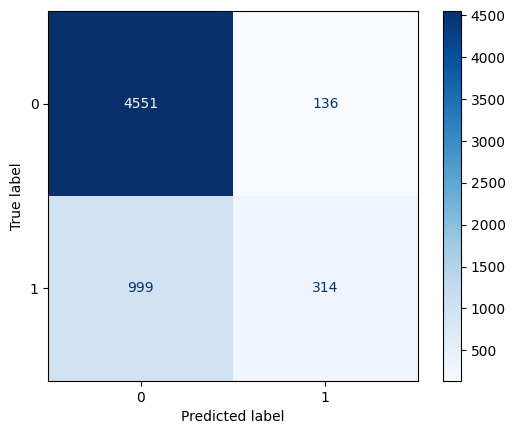

Saved results to results/model_results_cc.xlsx


In [28]:
fc.predict_binary_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original",
    epsilon=0,
    output_file="results/model_results_cc.xlsx"
)

In [29]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = True)

Accuracy: 0.8101
Precision: 0.7118
Recall: 0.2423
F1 Score: 0.3612
Time: 1.5525014400482178


{'fit_time': array([0.11930776, 0.1309092 , 0.1330235 , 0.14130998, 0.12978053,
        0.12537932, 0.10549545, 0.14055872, 0.22494626, 0.15008235]),
 'score_time': array([0.01856637, 0.01021743, 0.01263261, 0.01178455, 0.01107645,
        0.01625609, 0.01078701, 0.01361513, 0.01610661, 0.01549363]),
 'test_accuracy': array([0.80083333, 0.81166667, 0.82      , 0.81208333, 0.80416667,
        0.81125   , 0.81375   , 0.81041667, 0.81416667, 0.8025    ]),
 'test_precision': array([0.64673913, 0.7       , 0.78089888, 0.73684211, 0.68902439,
        0.74842767, 0.72251309, 0.72413793, 0.71641791, 0.65284974]),
 'test_recall': array([0.22368421, 0.26315789, 0.2612782 , 0.23684211, 0.21240602,
        0.22368421, 0.2593985 , 0.23639775, 0.27016886, 0.23639775]),
 'test_f1': array([0.33240223, 0.38251366, 0.3915493 , 0.35846373, 0.32471264,
        0.34442836, 0.38174274, 0.35643564, 0.39237057, 0.34710744])}

In [30]:
fc.hyperparameterTuning_save_Results(X_train_sc, y_train, cv=10, bivariate = True, perturbation_type="Original_hpt",
        epsilon=0, output_file="results/model_results_cc.xlsx")

Best parameters: {'C': 100}
Accuracy : 0.8102
Precision: 0.7127
Recall   : 0.2425
F1 Score : 0.3615
Time     : 11.38 s


(LogisticRegression(C=100, max_iter=1000), {'C': 100})

In [31]:
X_all = pd.concat([X_train_sc, X_test_sc], axis=0)
orig_confidence_scores = model.predict_proba(X_all)

with open("orig_confidence_scores_creditcard.pkl", "wb") as f:
    pickle.dump(orig_confidence_scores, f)

----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

### Perturb dataset

In [32]:
print(X_train.columns)

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'MARRIAGE_2', 'MARRIAGE_3', 'SEX_2',
       'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5',
       'EDUCATION_6'],
      dtype='object')


In [33]:
ranges = [[1000,1000000], [18,100], [-2,8], [-2,8], [-2,8], [-2,8], [-2,8],
       [-2,8], [-10000,500000], [-10000,500000], [-10000,500000], [-10000,500000],
       [-10000,500000],[-10000,500000], [0,250000], [0,250000], [0,250000],
       [0,250000], [0,250000], [0,250000], [0,1], [0,1], [0,1],
       [0,1], [0,1], [0,1], [0,1], [0,1]]
print(ranges)

sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)


[[1000, 1000000], [18, 100], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]]
[999000, 82, 10, 10, 10, 10, 10, 10, 510000, 510000, 510000, 510000, 510000, 510000, 250000, 250000, 250000, 250000, 250000, 250000, 1, 1, 1, 1, 1, 1, 1, 1]


In [34]:
X_train_clipped = X_train.copy()
for i, col in enumerate(X_train.columns):
    lower, upper = ranges[i]
    X_train_clipped[col] = X_train_clipped[col].clip(lower=lower, upper=upper)

In [35]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train_clipped.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train_clipped.columns):
        eps_j = e # The paper uses eps_j = e/d, but this leades to huge errors
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train_clipped))

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [36]:
input_confidence_scores = {}

for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input",
        epsilon=e,
        output_file="results/model_results_cc.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = True, perturbation_type="Input_hpt",
        epsilon=e, output_file="results/model_results_cc.xlsx")

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train_sc, X_test_sc], axis=0)
    input_confidence_scores[e] = input_model.predict_proba(X_all)

with open("input_confidence_scores_creditcard.pkl", "wb") as f:
    pickle.dump(input_confidence_scores, f)


Training set: 
---------------------------------------
Accuracy: 0.7782
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
---------------------------------------
Accuracy: 0.7812
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.7782
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
Time     : 0.74 s
Training set: 
---------------------------------------
Accuracy: 0.7782
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
---------------------------------------
Accuracy: 0.7812
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
Saved results to results/model_results_cc.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Best parameters: {'C': 0.01}
Accuracy : 0.7782
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
Time     : 0.58 s
Training set: 
---------------------------------------
Accuracy: 0.7810
Precision: 0.5793
Recall: 0.0453
F1 Score: 0.0840
---------------------------------------
---------------------------------------
Accuracy: 0.7832
Precision: 0.6364
Recall: 0.0213
F1 Score: 0.0413
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 100}
Accuracy : 0.7810
Precision: 0.5783
Recall   : 0.0447
F1 Score : 0.0830
Time     : 0.69 s
Training set: 
---------------------------------------
Accuracy: 0.7916
Precision: 0.6527
Recall: 0.1289
F1 Score: 0.2152
---------------------------------------
---------------------------------------
Accuracy: 0.7962
Precision: 0.6758
Recall: 0.1318
F1 Score: 0.2205
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.7909
Precision: 0.6520
Recall   : 0.1232
F1 Score : 0.2072
Time     : 0.69 s
Training set: 
---------------------------------------
Accuracy: 0.8057
Precision: 0.6962
Recall: 0.2200
F1 Score: 0.3343
---------------------------------------
---------------------------------------
Accuracy: 0.8107
Precision: 0.6911
Recall: 0.2437
F1 Score: 0.3604
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 1}
Accuracy : 0.8052
Precision: 0.6937
Recall   : 0.2189
F1 Score : 0.3324
Time     : 0.99 s
Training set: 
---------------------------------------
Accuracy: 0.8084
Precision: 0.7077
Recall: 0.2320
F1 Score: 0.3495
---------------------------------------
---------------------------------------
Accuracy: 0.8110
Precision: 0.6916
Recall: 0.2460
F1 Score: 0.3629
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 1}
Accuracy : 0.8083
Precision: 0.7104
Recall   : 0.2314
F1 Score : 0.3488
Time     : 1.15 s
Training set: 
---------------------------------------
Accuracy: 0.8104
Precision: 0.7135
Recall: 0.2423
F1 Score: 0.3618
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy: 0.8113
Precision: 0.6938
Recall: 0.2468
F1 Score: 0.3640
---------------------------------------
Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 1}
Accuracy : 0.8101
Precision: 0.7142
Recall   : 0.2407
F1 Score : 0.3596
Time     : 1.30 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [37]:
n = X_train.shape[0]
#C_x = np.max(np.linalg.norm(X_train, axis=1))
lambda_reg = 1 / model.C
sensitivity = (2) / (lambda_reg * n)

epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity / e,size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity / 3,size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [38]:
output_confidence_scores = {}

for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output",
        epsilon=e,
        output_file="results/model_results_cc.xlsx"
    )

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train_sc, X_test_sc], axis=0)
    output_confidence_scores[e] = output_model.predict_proba(X_all)

with open("output_confidence_scores_creditcard.pkl", "wb") as f:
    pickle.dump(output_confidence_scores, f)

Training set: 
---------------------------------------
Accuracy: 0.8111
Precision: 0.7178
Recall: 0.2442
F1 Score: 0.3645
---------------------------------------
---------------------------------------
Accuracy: 0.8105
Precision: 0.6973
Recall: 0.2369
F1 Score: 0.3536
---------------------------------------
Saved results to results/model_results_cc.xlsx
Training set: 
---------------------------------------
Accuracy: 0.8112
Precision: 0.7172
Recall: 0.2454
F1 Score: 0.3656
---------------------------------------
---------------------------------------
Accuracy: 0.8110
Precision: 0.6984
Recall: 0.2399
F1 Score: 0.3571
---------------------------------------
Saved results to results/model_results_cc.xlsx
Training set: 
---------------------------------------
Accuracy: 0.8112
Precision: 0.7174
Recall: 0.2452
F1 Score: 0.3654
---------------------------------------
---------------------------------------
Accuracy: 0.8108
Precision: 0.6978
Recall: 0.2391
F1 Score: 0.3562
-------------------

----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [39]:
data_norm = np.max(np.linalg.norm(np.asarray(X_train_sc), axis=1))
print("data_norm (max L2 norm of a scaled training row):", data_norm)


data_norm (max L2 norm of a scaled training row): 94.59893444466807


In [40]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]

internal_models = fc.internal_perturbation_save_results(
    "creditcard",
    X_train_sc,
    y_train,
    X_test_sc,
    y_test,
    epsilon_values=epsilon_values,
    data_norm=data_norm,
    C=model.C,
    bivariate=True,
    output_file="results/model_results_cc.xlsx",
    perturbation_type="Internal"
)



---------------------------------------
Epsilon: 0.1
Accuracy: 0.6265
Precision: 0.2434
Recall: 0.3351
F1 Score: 0.2820
Time: 0.04 s
---------------------------------------
---------------------------------------
Epsilon: 1
Accuracy: 0.7000
Precision: 0.3087
Recall: 0.2993
F1 Score: 0.3039
Time: 0.05 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 5
Accuracy: 0.7495
Precision: 0.3963
Recall: 0.2765
F1 Score: 0.3257
Time: 0.39 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 10
Accuracy: 0.7448
Precision: 0.3895
Recall: 0.2925
F1 Score: 0.3341
Time: 0.51 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 30
Accuracy: 0.8042
Precision: 0.6444
Recall: 0.2346
F1 Score: 0.3439
Time: 0.45 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 50
Accuracy: 0.8075
Precision: 0.6763
Recall: 0.2308
F1 Score: 0.3441
Time: 0.41 s
---------------------------------------
---------------------------------------
Epsilon: 100
Accuracy: 0.8110
Precision: 0.7039
Recall: 0.2353
F1 Score: 0.3527
Time: 0.13 s
---------------------------------------
Saved results to results/model_results_cc.xlsx
